# Student Performance Prediction - walkthrough projekta

Ovaj notebook prikazuje tok projekta za predikciju završne ocene učenika. Fokus je na rezultatima koji su već generisani kroz Python skripte: CSV izveštajima, grafičkim prikazima, poređenju modela i finalnom načinu korišćenja modela.

Notebook ne trenira modele i ne menja fajlove u projektu. Služi kao pregledan walkthrough za prikaz projekta na odbrani.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
LOGS_DIR = DATA_DIR / "logs"
GRAPHS_DIR = DATA_DIR / "graphs"
MODELS_DIR = PROJECT_ROOT / "models"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)

# Step 01
step01_logs = LOGS_DIR / "step01_data_preparation"
dataset_overview = pd.read_csv(step01_logs / "dataset_overview.csv")
features_overview = pd.read_csv(step01_logs / "features_overview.csv")
preprocessing_report = pd.read_csv(step01_logs / "preprocessing_report.csv")

# Step 02
step02_logs = LOGS_DIR / "step02_eda"
step02_graphs = GRAPHS_DIR / "step02_eda"
eda_report = pd.read_csv(step02_logs / "eda_report.csv")
step02_graph_items = [
    ("Raspodela G3", step02_graphs / "g3_distribution.png"),
    ("Korelaciona matrica", step02_graphs / "numeric_correlation_matrix.png"),
    ("G1 vs G3", step02_graphs / "g1_vs_g3.png"),
    ("G2 vs G3", step02_graphs / "g2_vs_g3.png"),
    ("Failures vs G3", step02_graphs / "failures_vs_g3.png"),
    ("Studytime vs G3", step02_graphs / "studytime_vs_g3.png"),
    ("Absences distribution", step02_graphs / "absences_distribution.png"),
]

# Step 03
step03_logs = LOGS_DIR / "step03_data_split"
split_report = pd.read_csv(step03_logs / "split_report.csv")

# Step 04/05
step04_logs = LOGS_DIR / "step04_model_training"
step05_graphs = GRAPHS_DIR / "step05_model_comparison"
model_comparison_report = pd.read_csv(step04_logs / "model_comparison_report.csv")
step05_graph_items = [
    ("Validation metrics comparison", step05_graphs / "validation_metrics_comparison.png"),
    ("Test metrics comparison", step05_graphs / "test_metrics_comparison.png"),
]

# Step 06/07
step06_logs = LOGS_DIR / "step06_hyperparameter_tuning"
step07_graphs = GRAPHS_DIR / "step07_tuning_graphs"
tuning_details = pd.read_csv(step06_logs / "hyperparameter_tuning_details.csv")
tuning_summary = pd.read_csv(step06_logs / "hyperparameter_tuning_summary.csv")
step07_graph_items = [
    ("Default vs tuned - validation", step07_graphs / "default_vs_tuned_validation.png"),
    ("Default vs tuned - test", step07_graphs / "default_vs_tuned_test.png"),
]

# Step 08
step08_logs = LOGS_DIR / "step08_feature_importance"
step08_graphs = GRAPHS_DIR / "step08_feature_importance"
feature_importance_with_g1_g2 = pd.read_csv(step08_logs / "feature_importance_with_G1_G2.csv")
feature_importance_without_g1_g2 = pd.read_csv(step08_logs / "feature_importance_without_G1_G2.csv")
step08_graph_items = [
    ("Feature importance sa G1/G2", step08_graphs / "feature_importance_with_G1_G2.png"),
    ("Feature importance bez G1/G2", step08_graphs / "feature_importance_without_G1_G2.png"),
]

# Step 09
step09_logs = LOGS_DIR / "step09_top_features"
step09_graphs = GRAPHS_DIR / "step09_top_features"
top_features_with_g1_g2 = pd.read_csv(step09_logs / "top_features_with_G1_G2.csv")
top_features_without_g1_g2 = pd.read_csv(step09_logs / "top_features_without_G1_G2.csv")
top_features_tuning_details = pd.read_csv(step09_logs / "top_features_tuning_details.csv")
top_features_model_report = pd.read_csv(step09_logs / "top_features_model_comparison_report.csv")
step09_graph_items = [
    ("Top features comparison - validation", step09_graphs / "validation_top_features_comparison.png"),
    ("Top features comparison - test", step09_graphs / "test_top_features_comparison.png"),
]

# Step 10
step10_logs = LOGS_DIR / "step10_final_model_selection"
step10_graphs = GRAPHS_DIR / "step10_final_model_selection"
final_model_report = pd.read_csv(step10_logs / "final_model_report.csv")
final_model_predictions = pd.read_csv(step10_logs / "final_model_predictions.csv")
step10_graph_items = [
    ("Final model metrics", step10_graphs / "final_model_metrics.png"),
    ("Actual vs predicted", step10_graphs / "final_model_actual_vs_predicted.png"),
    ("Residuals", step10_graphs / "final_model_residuals.png"),
]


def show_graphs(graphs):
    for title, graph_path in graphs:
        print(title)
        display(Image(filename=str(graph_path)))



## 1. Cilj projekta i opis problema

Cilj projekta je da se razvije model koji predviđa završnu ocenu učenika, odnosno promenljivu **G3**, na osnovu podataka iz fajla `data/raw/student-por.csv`.

Podaci sadrže demografske, porodične, školske i ponašajne atribute učenika, kao i ocene tokom školske godine. Ocene su na skali **0-20**:

- **G1** - ocena iz prvog perioda;
- **G2** - ocena iz drugog perioda;
- **G3** - završna ocena i target promenljiva.

Problem je regresioni jer model predviđa numeričku vrednost, a ne klasu. Posebno važan deo projekta je poređenje scenarija u kojima se koriste prethodne ocene `G1` i `G2` sa scenarijima u kojima se one izostavljaju. Scenarij sa `G1/G2` je obično precizniji, dok scenarij bez `G1/G2` ima praktičnu vrednost za raniju procenu uspeha.


## 2. Pregled dataset-a i početna obrada

Prvi korak proverava osnovno stanje dataset-a: broj redova i kolona, tipove atributa, nedostajuće vrednosti, duplikate i osnovne anomalije. U ovoj fazi se ne radi enkodiranje celog dataset-a unapred.

Numerički atributi se kasnije obrađuju pomoću `StandardScaler`, a kategorijski pomoću `OneHotEncoder`. Oba transformatora se koriste unutar `sklearn Pipeline` objekta tokom treniranja modela. To je važno jer se transformatori fituju samo na train skupu, pa validation i test skup ne učestvuju u učenju preprocessing-a. Time se izbegava **data leakage**.


In [2]:
display(dataset_overview)
display(preprocessing_report)


,Opis,Vrednost
0,Broj redova,649.00
1,Broj kolona,33.00
2,Broj duplikata,0.00
3,Ukupan broj nedostajućih vrednosti,0.00
4,Broj numeričkih kolona,16.00
5,Broj kategorijskih kolona,17.00
6,Minimalna završna ocena G3,0.00
7,Maksimalna završna ocena G3,19.00
8,Prosečna završna ocena G3,11.91
9,Prosečna ocena G1,11.40


,Opis,Vrednost
0,Missing vrednosti,0
1,Duplikati,0
2,G1 van opsega 0-20,Ne
3,G2 van opsega 0-20,Ne
4,G3 van opsega 0-20,Ne
5,Age anomalije,Ne
6,Maksimalan broj izostanaka,32
7,Ciljna promenljiva,G3
8,Scenario sa G1 i G2,32 atributa; koriste se svi ulazni atributi osim G3.
9,Scenario bez G1 i G2,"30 atributa; koriste se svi ulazni atributi osim G1, G2 i G3."


Iz ovih izveštaja se vidi da dataset ima 649 redova i 33 kolone, bez nedostajućih vrednosti i duplikata. Atributi su mešavina numeričkih i kategorijskih kolona. U početnoj obradi nisu pronađene očigledne kolone ili redovi koje treba ukloniti, pa se glavni preprocessing namerno odlaže za pipeline unutar modelovanja.


## 3. Eksplorativna analiza podataka

Eksplorativna analiza proverava raspodelu završne ocene, korelacije numeričkih atributa i potencijalno neobične vrednosti. Posebno su bitne veze `G1-G3` i `G2-G3`, jer prethodne ocene direktno opisuju raniji uspeh istog učenika.


In [3]:
display(eda_report)


,Opis,Vrednost
0,Broj učenika,649
1,Minimalna G3 ocena,0
2,Maksimalna G3 ocena,19
3,Prosečna G3 ocena,11.91
4,Broj učenika sa G3 = 0,15
5,Procenat učenika sa G3 = 0,2.31
6,Korelacija G1 i G3,0.83
7,Korelacija G2 i G3,0.92
8,Korelacija G1 i G2,0.86
9,Korelacija failures i G3,-0.39


Raspodela G3


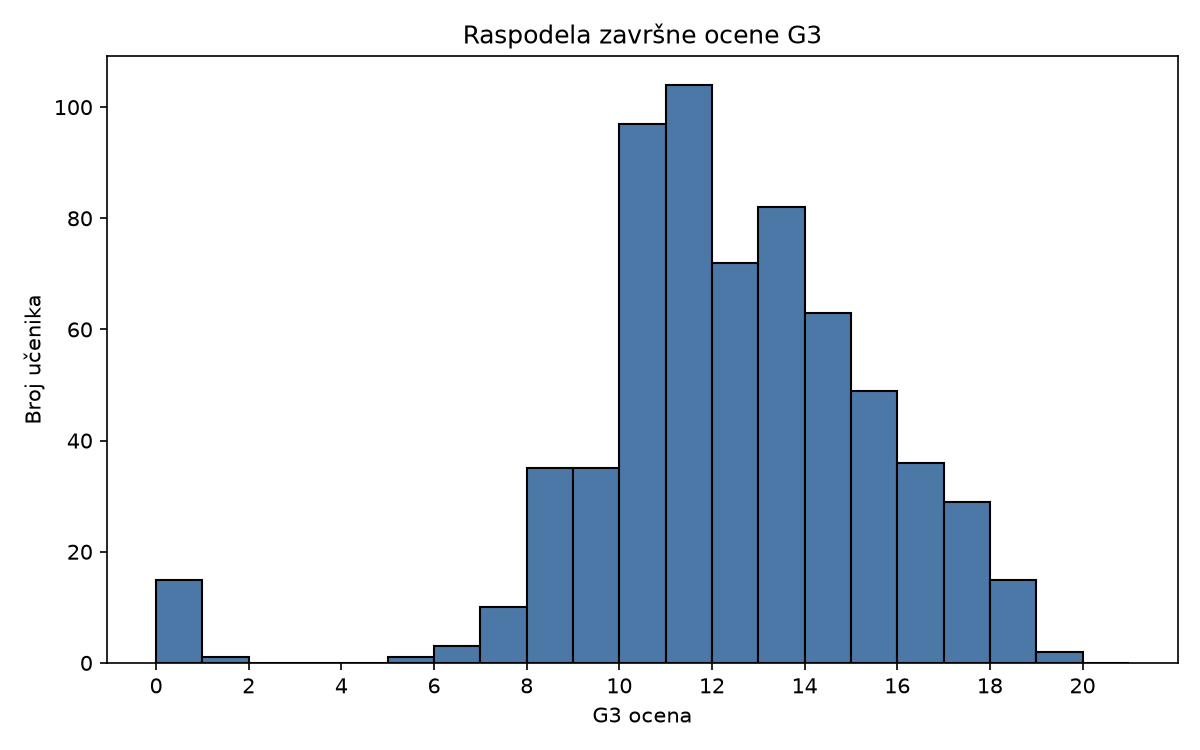

Korelaciona matrica


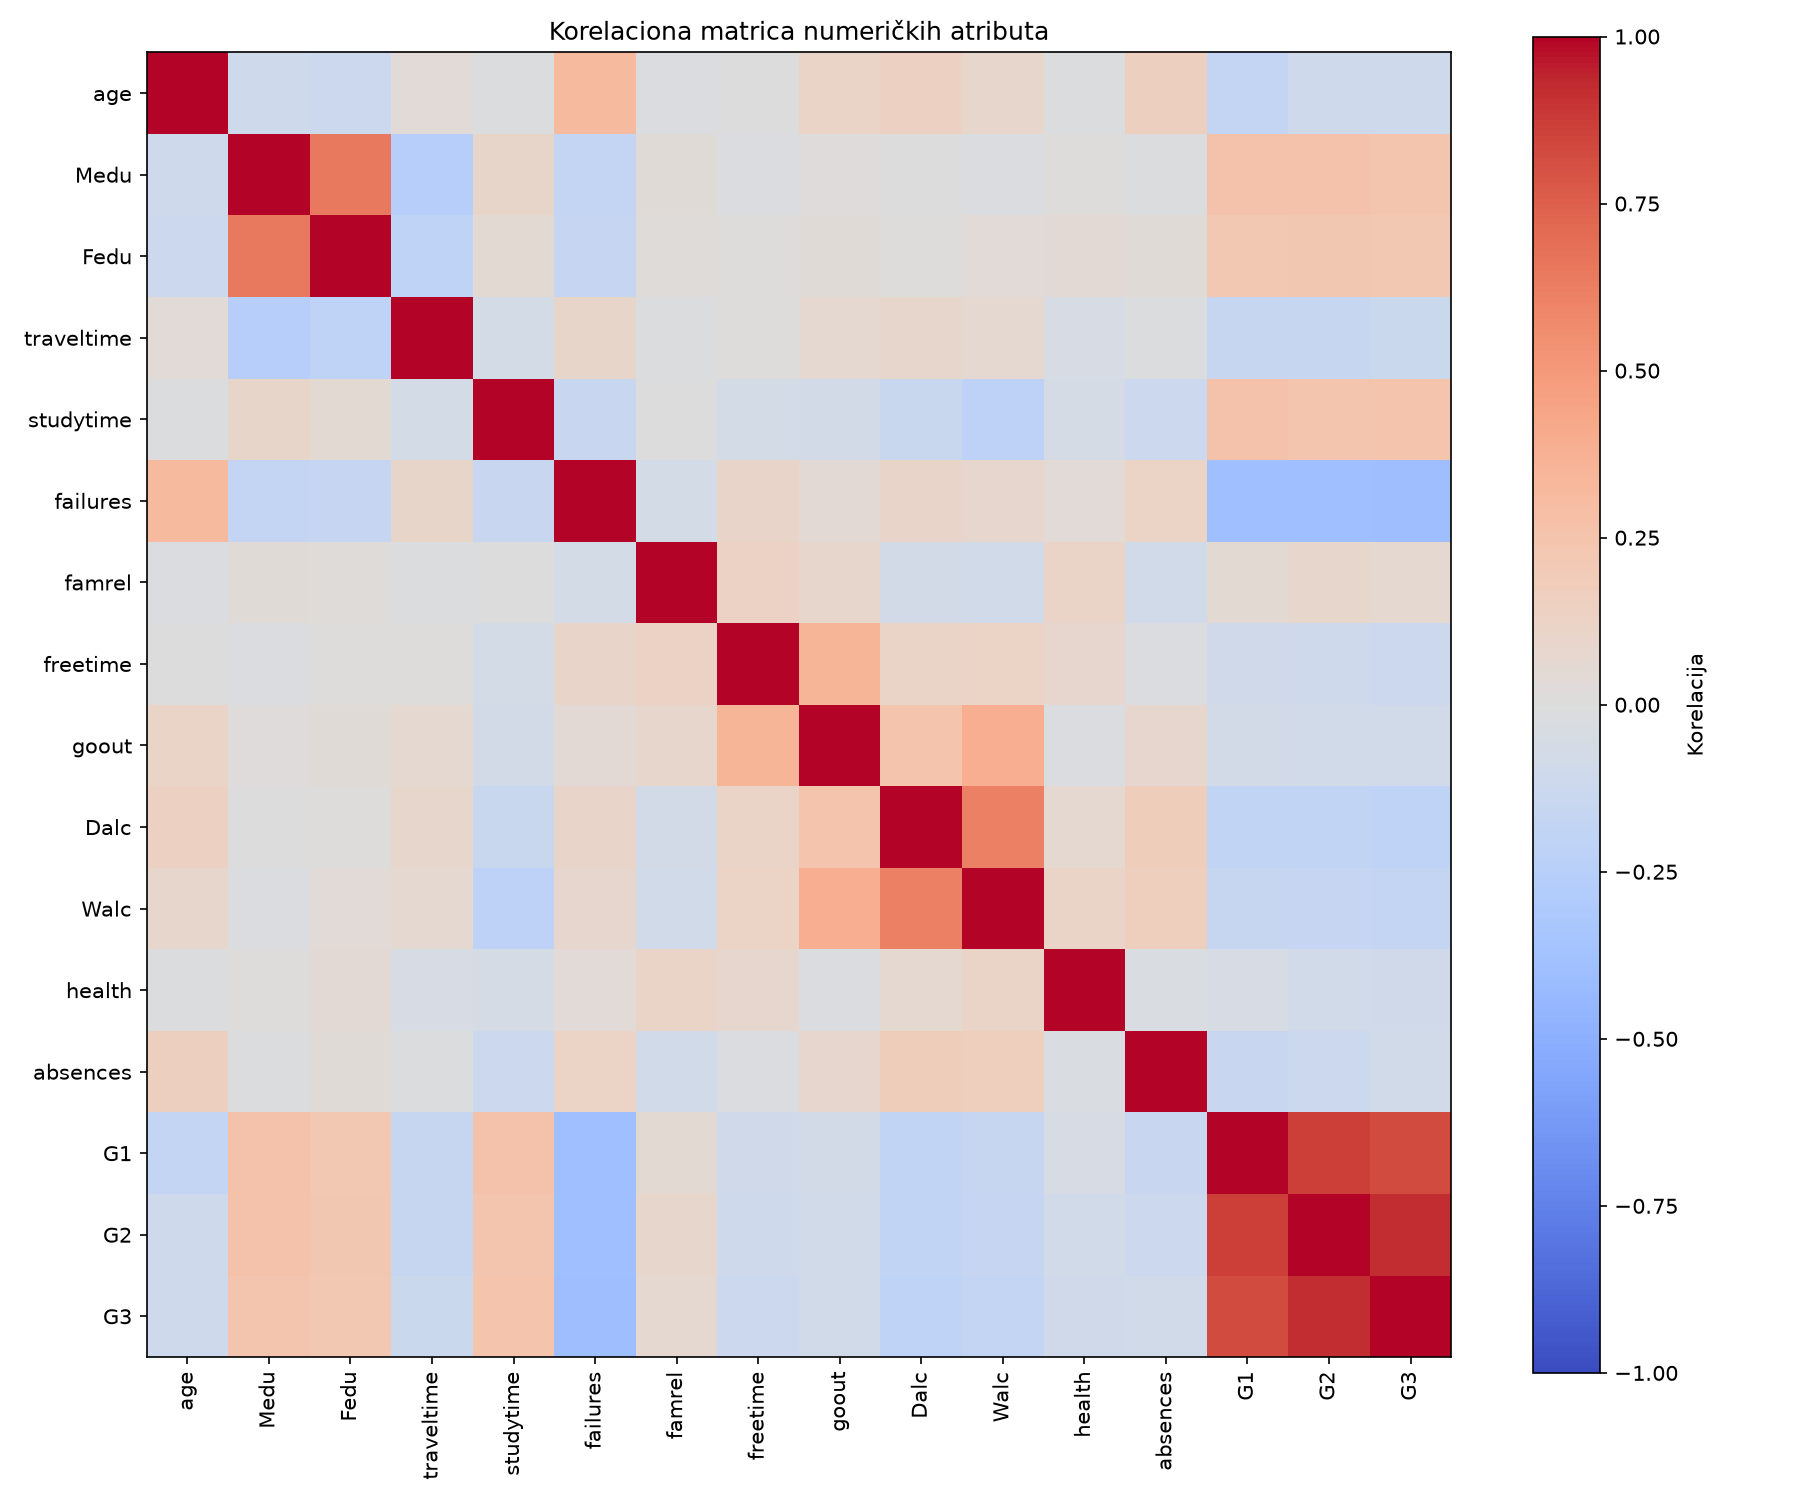

G1 vs G3


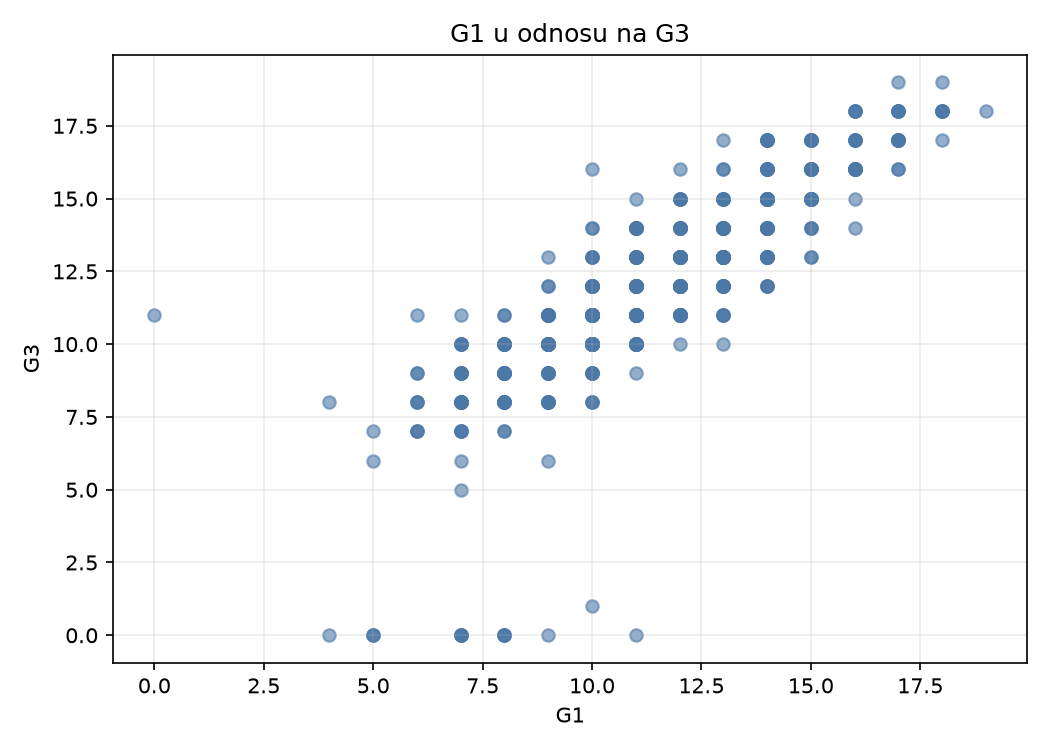

G2 vs G3


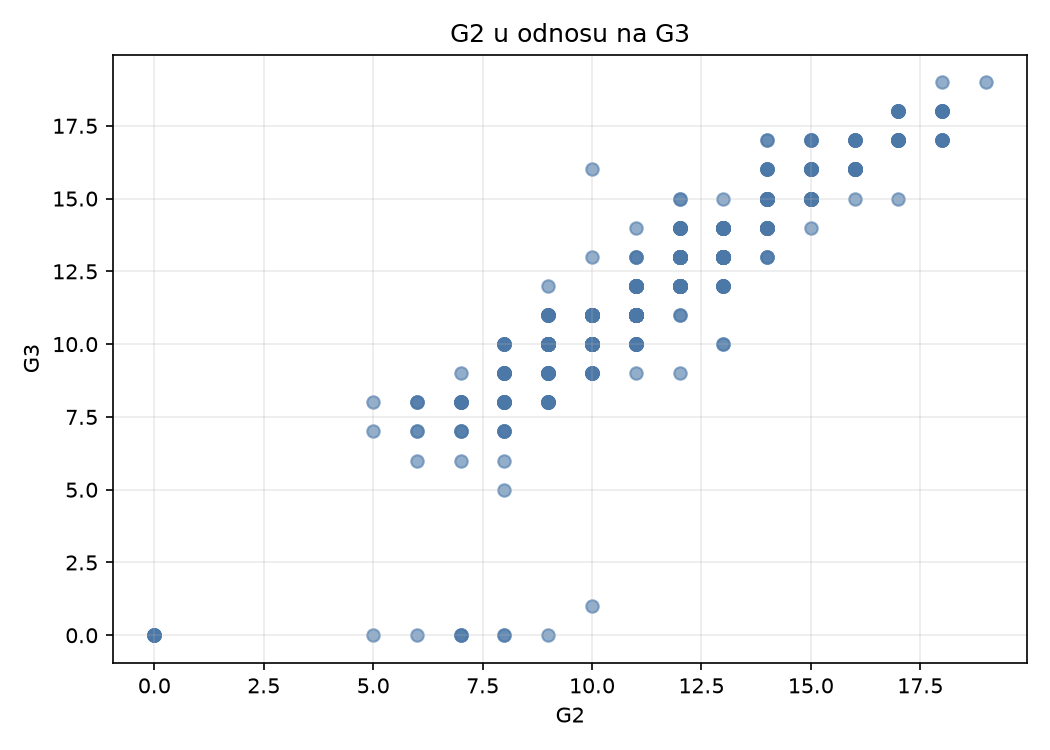

Failures vs G3


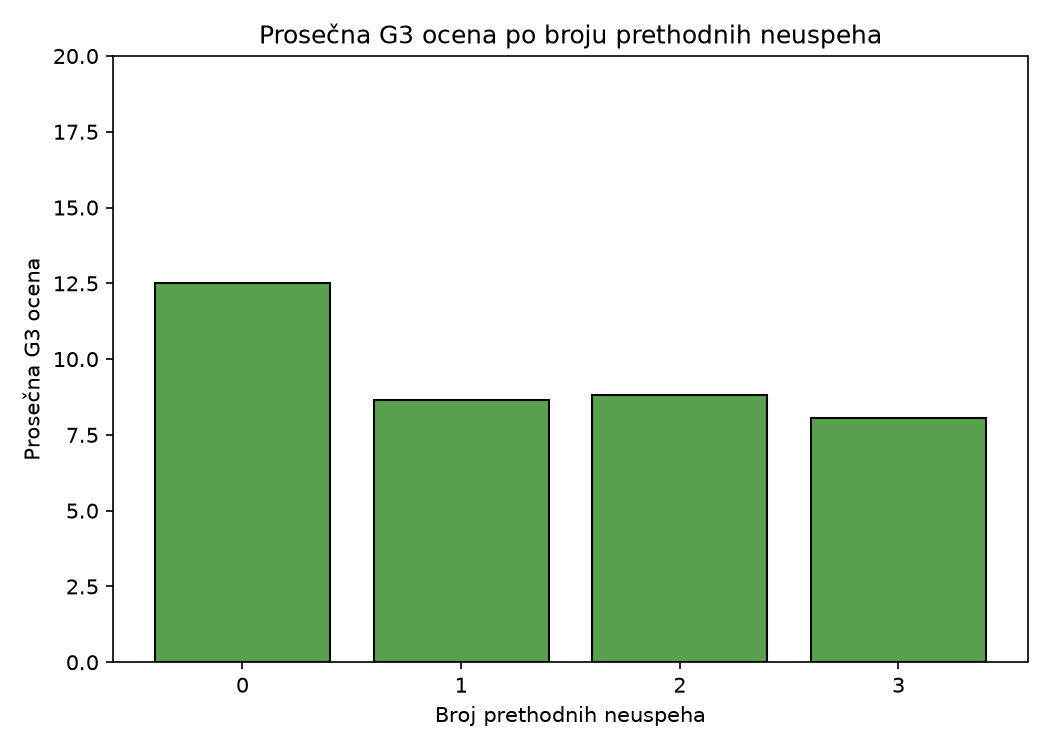

Studytime vs G3


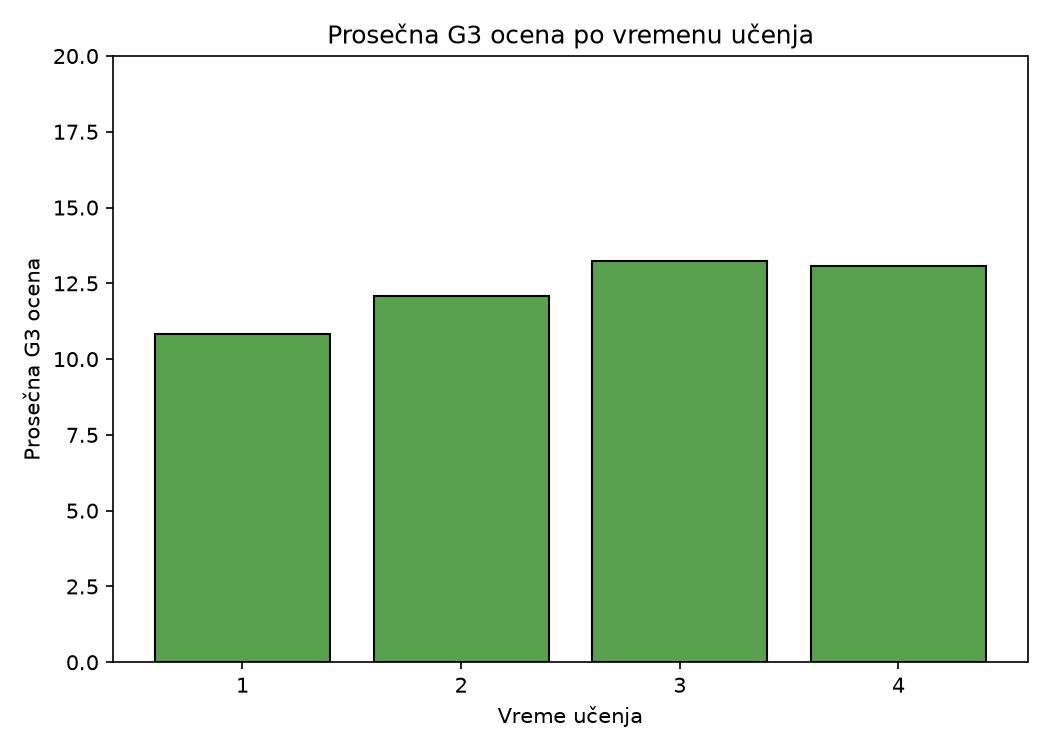

Absences distribution


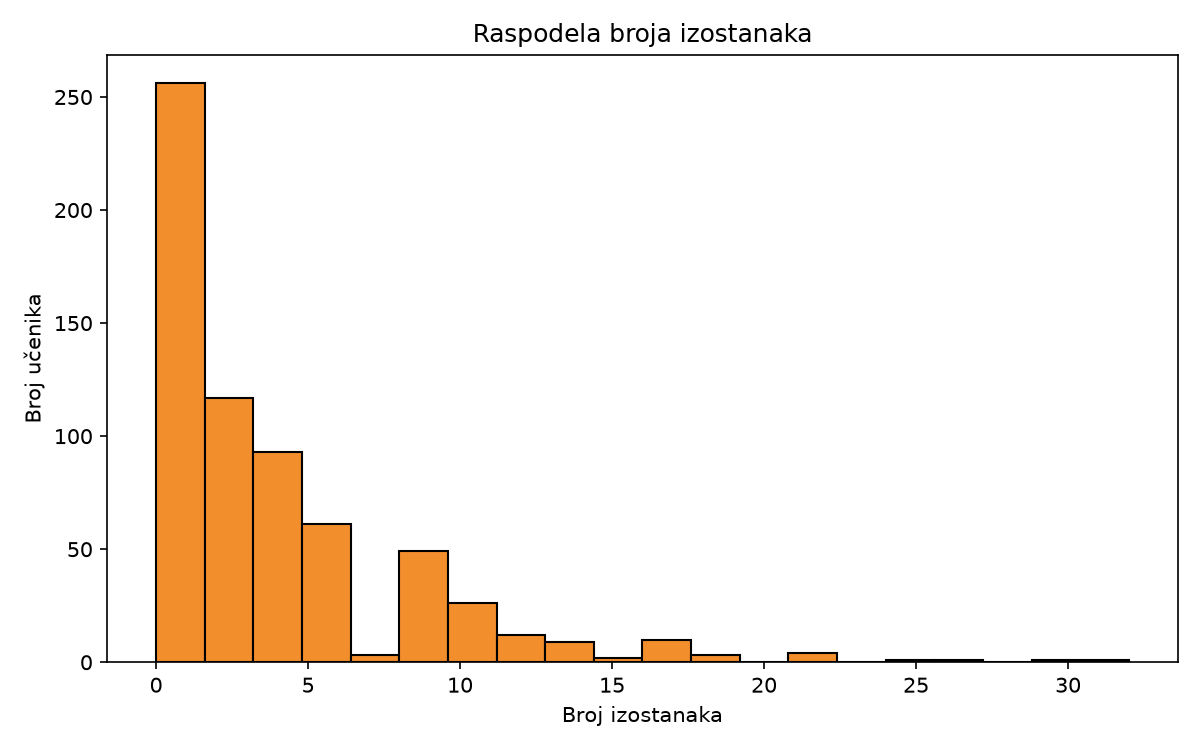

In [4]:
show_graphs(step02_graph_items)


EDA potvrđuje da su `G1` i posebno `G2` najjače povezani sa završnom ocenom `G3`. Zbog toga je opravdano da se modeli porede u dve osnovne varijante: sa prethodnim ocenama i bez njih.

Vrednosti kao što su `G3 = 0` i veći broj izostanaka su evidentirane kao potencijalno neobične ili ekstremne, ali se ne brišu automatski. One mogu predstavljati realne slučajeve u podacima, pa ih je bezbednije zadržati dok se ne pokaže jasan razlog za uklanjanje.


## 4. Podela podataka

Dataset je jednom podeljen na train, validation i test skup. Ista podela se koristi za sve modele i sve scenarije, pa poređenje ne zavisi od toga koji su redovi završili u kom skupu.


In [5]:
display(split_report)


,Opis,Vrednost
0,Izvorni dataset,data/raw/student-por.csv
1,Ciljna promenljiva,G3
2,Random state,42
3,Ukupan broj redova,649
4,Train redovi,454
5,Validation redovi,97
6,Test redovi,98
7,Train procenat,69.95
8,Validation procenat,14.95
9,Test procenat,15.10


Train skup služi za obučavanje modela, validation skup za poređenje modela i izbor hiperparametara, a test skup za završnu proveru rezultata. Ovakva podela čuva test skup od uticaja na izbor modela.


## 5. Osnovno treniranje modela

U početnom modelovanju porede se tri modela:

- `DummyRegressor` - baseline model koji daje referentni minimum kvaliteta;
- `Ridge Regression` - linearan regresioni model sa regularizacijom;
- `RandomForestRegressor` - nelinearan ansambl model koji može da uhvati složenije odnose u podacima.

Korišćene metrike su **MAE**, **RMSE** i **R2**. MAE pokazuje prosečnu apsolutnu grešku, RMSE jače kažnjava veće greške, dok R2 pokazuje koliki deo varijanse target promenljive model objašnjava. Za MAE i RMSE manje vrednosti su bolje, a za R2 veće vrednosti su bolje.


In [6]:
display(model_comparison_report)


,scenario,model,validation_MAE,validation_RMSE,validation_R2,test_MAE,test_RMSE,test_R2
0,with_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
1,with_G1_G2,Ridge Regression,0.7686,1.0555,0.8867,0.8204,1.3314,0.8530
2,with_G1_G2,RandomForestRegressor,0.7058,0.9862,0.9011,0.8556,1.3905,0.8397
3,without_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
4,without_G1_G2,Ridge Regression,2.1183,2.8668,0.1639,2.3377,3.0243,0.2416
5,without_G1_G2,RandomForestRegressor,2.0923,2.7779,0.2150,2.1971,2.9105,0.2976


Osnovni rezultati jasno pokazuju razliku između scenarija sa i bez `G1/G2`. Kada model vidi prethodne ocene, predikcija je znatno preciznija. Bez `G1/G2`, model se oslanja na posrednije atribute, pa su greške veće i R2 je niži.


## 6. Grafičko poređenje osnovnih modela

Grafici prikazuju iste metrike kao CSV report, ali omogućavaju lakše poređenje modela po scenarijima i skupovima podataka.


Validation metrics comparison


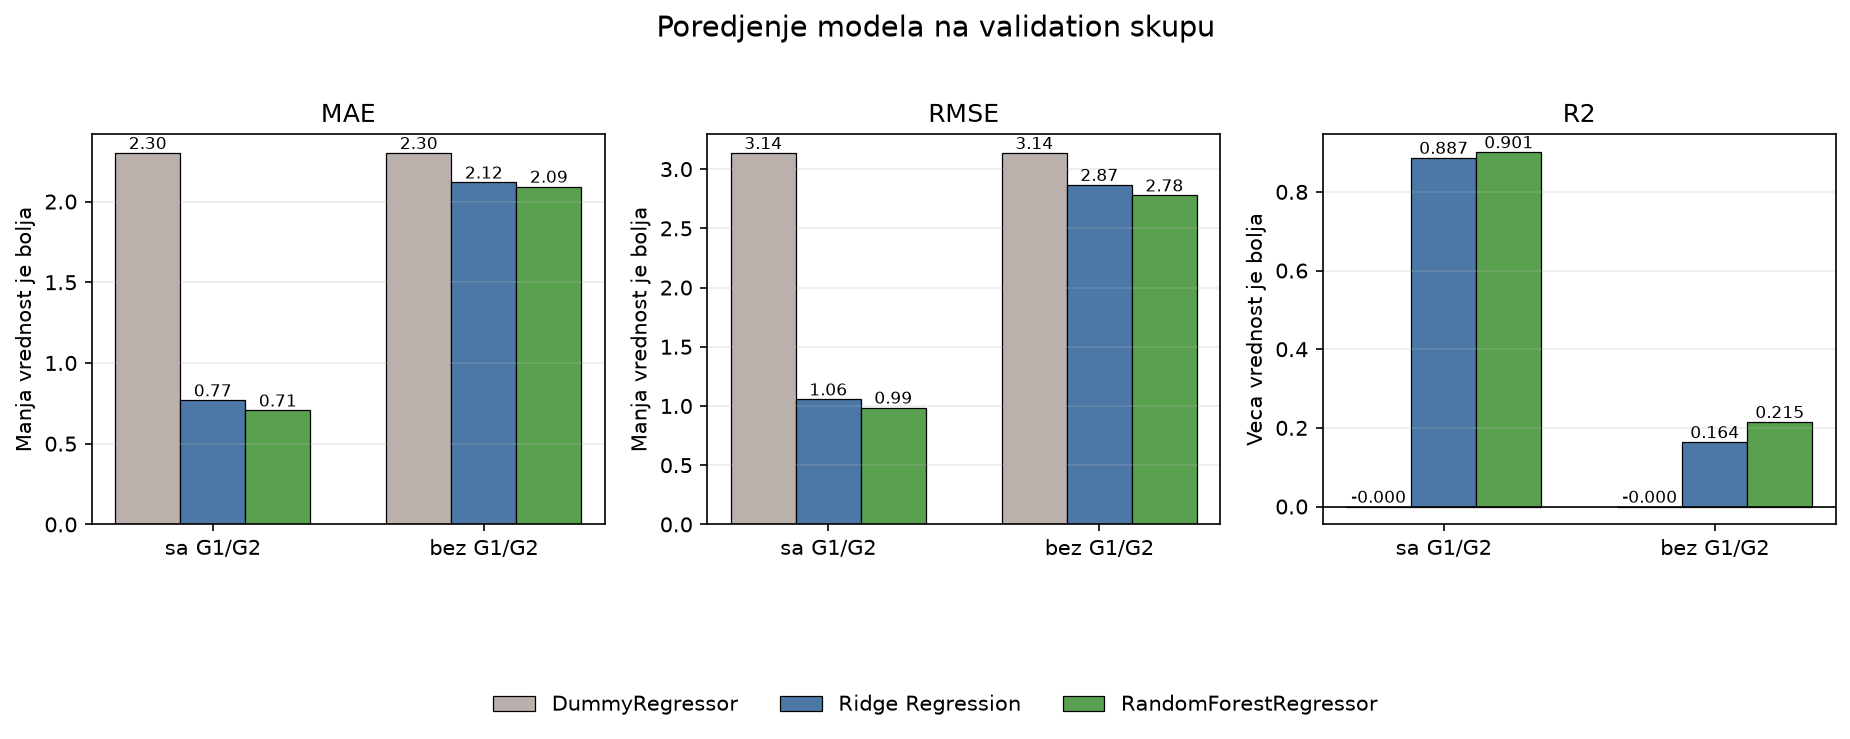

Test metrics comparison


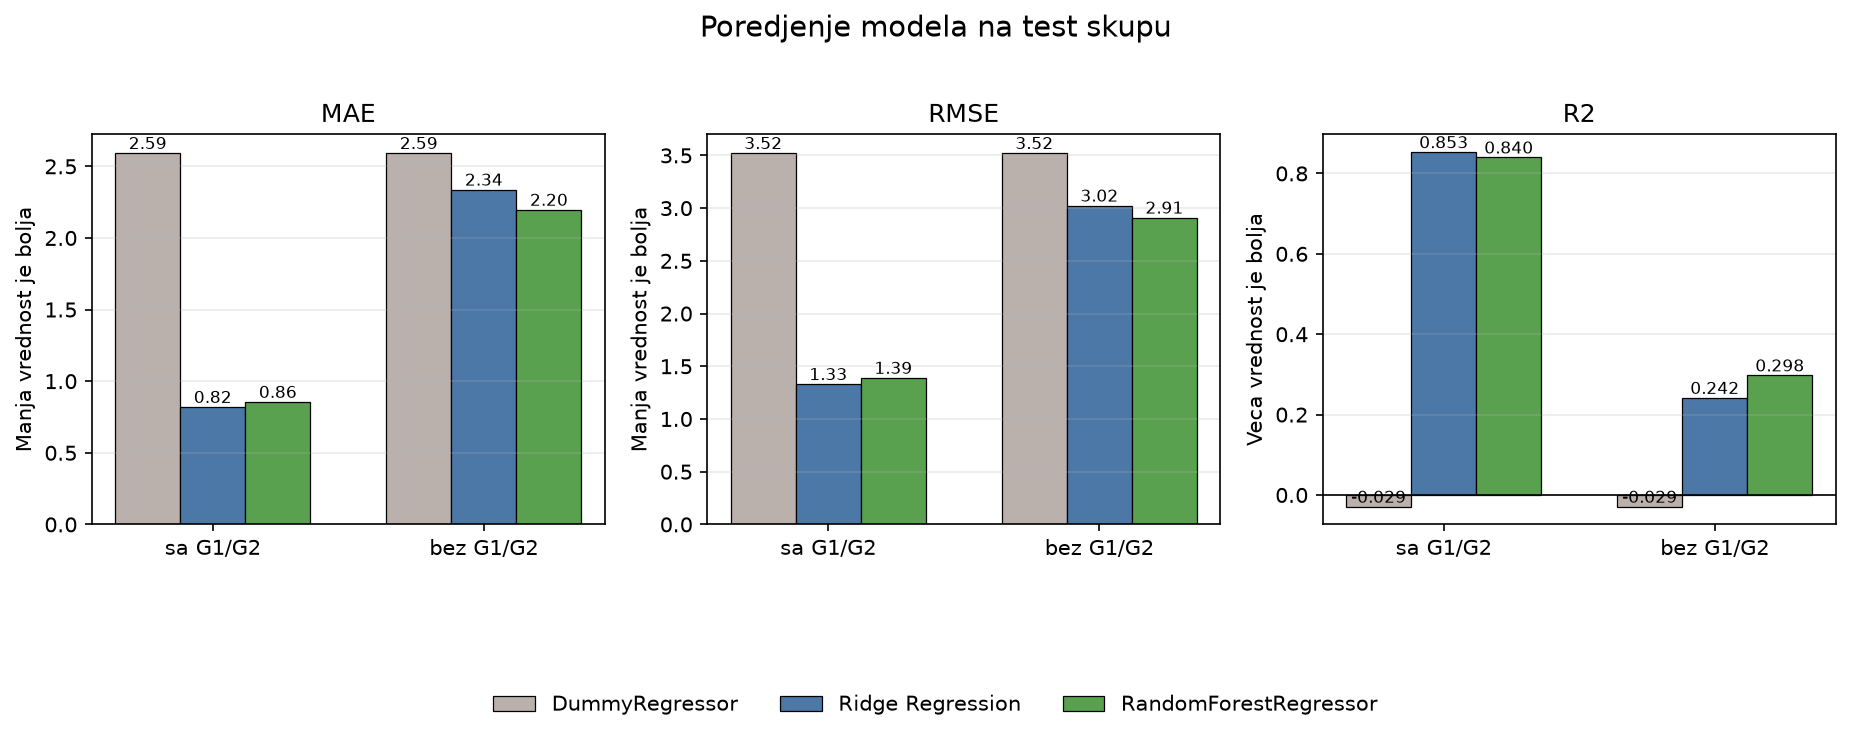

In [7]:
show_graphs(step05_graph_items)


## 7. Podešavanje hiperparametara

Podešavanje hiperparametara se radi prema validation rezultatima. U skripti `step06_hyperparameter_tuning.py` korišćen je ručni grid search: unapred je definisana mala mreža kandidata za `Ridge Regression` i `RandomForestRegressor`, zatim se treniraju sve kombinacije i porede po `validation_RMSE`.

Test skup se ne koristi za izbor parametara, već ostaje za proveru kako izabrani model radi na odvojenim podacima. Detaljni report prikazuje najbolje kombinacije parametara, dok summary report prikazuje izabrane kombinacije po modelu i scenariju.


In [8]:
best_tuning_rows = tuning_details[tuning_details["is_best"] == "Da"]

display(best_tuning_rows)
display(tuning_summary)


,scenario,model,parameters,validation_MAE,validation_RMSE,validation_R2,is_best
0,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=5; min_samples_leaf=5,0.6553,0.8831,0.9207,Da
1,with_G1_G2,Ridge Regression,alpha=10.0,0.7464,1.0457,0.8888,Da
2,without_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=10; min_samples_leaf=2,2.0547,2.7633,0.2232,Da
3,without_G1_G2,Ridge Regression,alpha=100.0,2.0021,2.7782,0.2148,Da


,scenario,model,best_parameters,selection_metric,validation_MAE,validation_RMSE,validation_R2,test_MAE,test_RMSE,test_R2
0,with_G1_G2,Ridge Regression,alpha=10.0,validation_RMSE,0.7464,1.0457,0.8888,0.8256,1.3370,0.8518
1,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=5; min_samples_leaf=5,validation_RMSE,0.6553,0.8831,0.9207,0.8287,1.4138,0.8343
2,without_G1_G2,Ridge Regression,alpha=100.0,validation_RMSE,2.0021,2.7782,0.2148,2.1474,2.9202,0.2929
3,without_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=10; min_samples_leaf=2,validation_RMSE,2.0547,2.7633,0.2232,2.1991,2.9108,0.2974


Redovi označeni kao najbolji biraju se prema validation rezultatu. To znači da tuning pokušava da poboljša generalizaciju, ali se kvalitet odluke i dalje mora proveriti na test skupu.


## 8. Default vs tuned modeli

Sledeći grafici porede default i tuned varijante modela. Cilj je da se vidi da li podešavanje hiperparametara stvarno poboljšava rezultate i da li se poboljšanje vidi i na test skupu.


Default vs tuned - validation


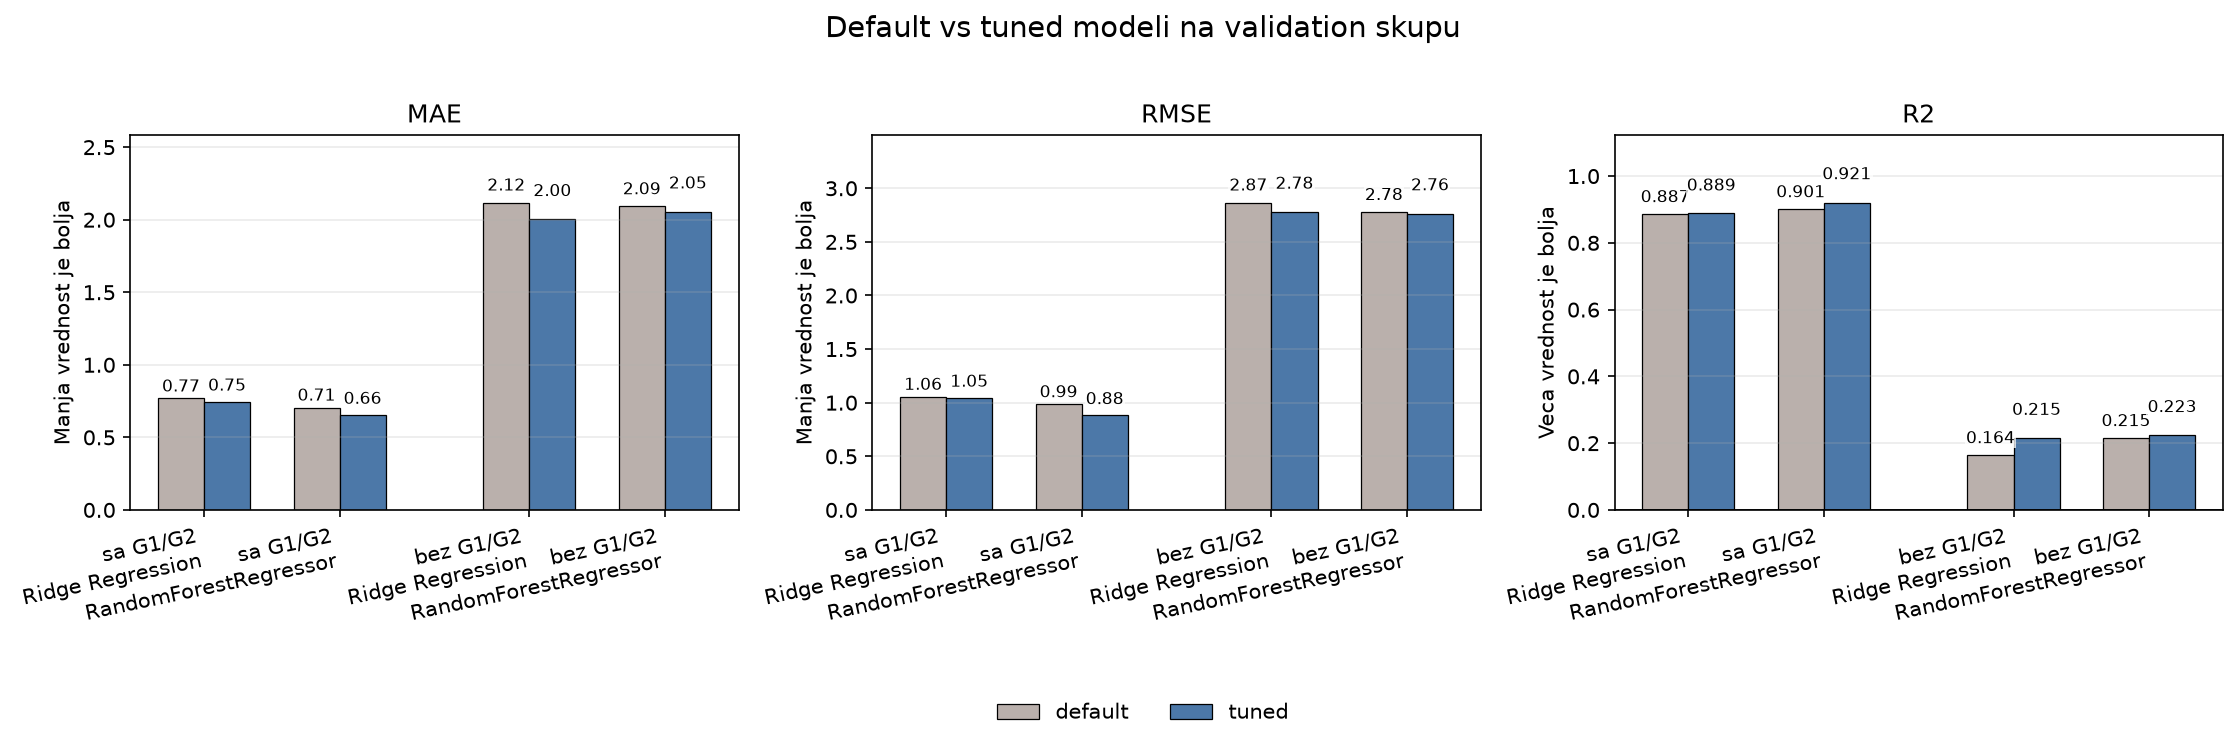

Default vs tuned - test


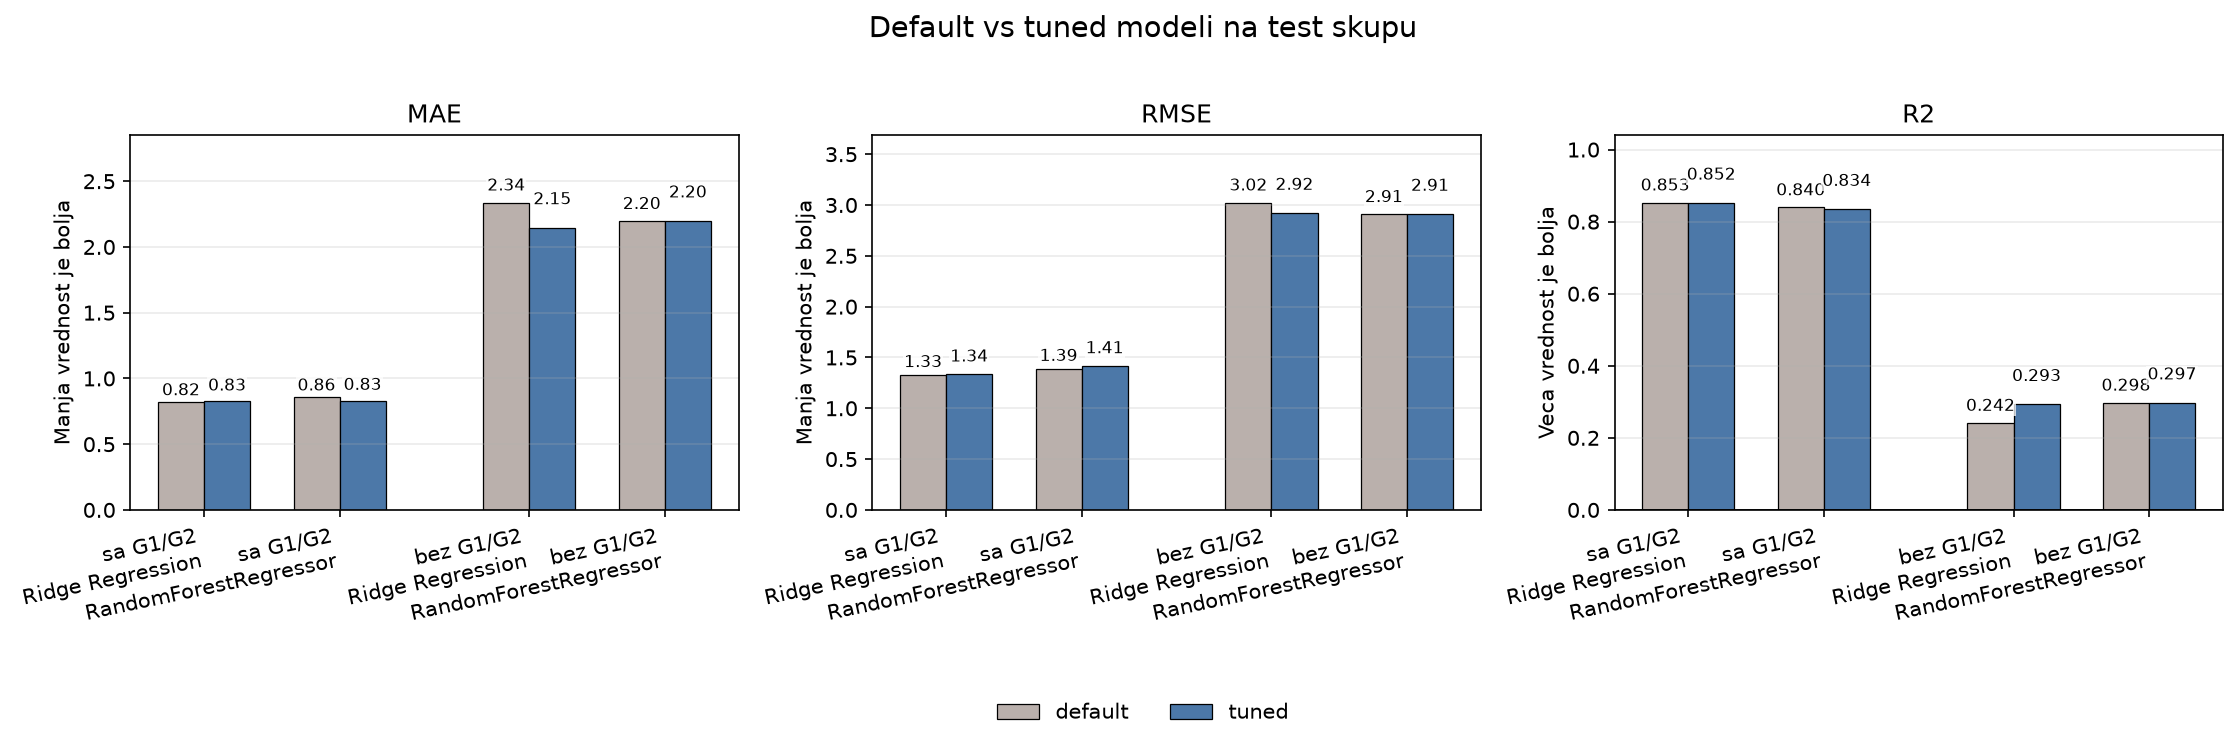

In [9]:
show_graphs(step07_graph_items)


Tuning može da poboljša validation rezultat, ali ne mora uvek jednako da popravi test rezultat. Zato se rezultati ne posmatraju samo po jednoj metrici, već kroz odnos validation/test performansi, jednostavnost modela i praktičnu upotrebljivost scenarija.


## 9. Feature importance

Feature importance analiza koristi `RandomForestRegressor` da proceni koji atributi najviše doprinose predikciji. Analiza je urađena posebno za scenario sa `G1/G2` i za scenario bez `G1/G2`.


In [10]:
display(feature_importance_with_g1_g2.head(10))
display(feature_importance_without_g1_g2.head(10))


,rank,feature,importance
0,1,G2,0.896595
1,2,absences,0.036763
2,3,G1,0.014654
3,4,age,0.012926
4,5,reason,0.005317
5,6,freetime,0.005300
6,7,health,0.003636
7,8,Fedu,0.002579
8,9,school,0.002357
9,10,failures,0.002284


,rank,feature,importance
0,1,failures,0.247520
1,2,reason,0.060714
2,3,absences,0.052936
3,4,school,0.047109
4,5,higher,0.043482
5,6,age,0.039692
6,7,Fedu,0.036970
7,8,health,0.034622
8,9,Dalc,0.032454
9,10,studytime,0.031868


Feature importance sa G1/G2


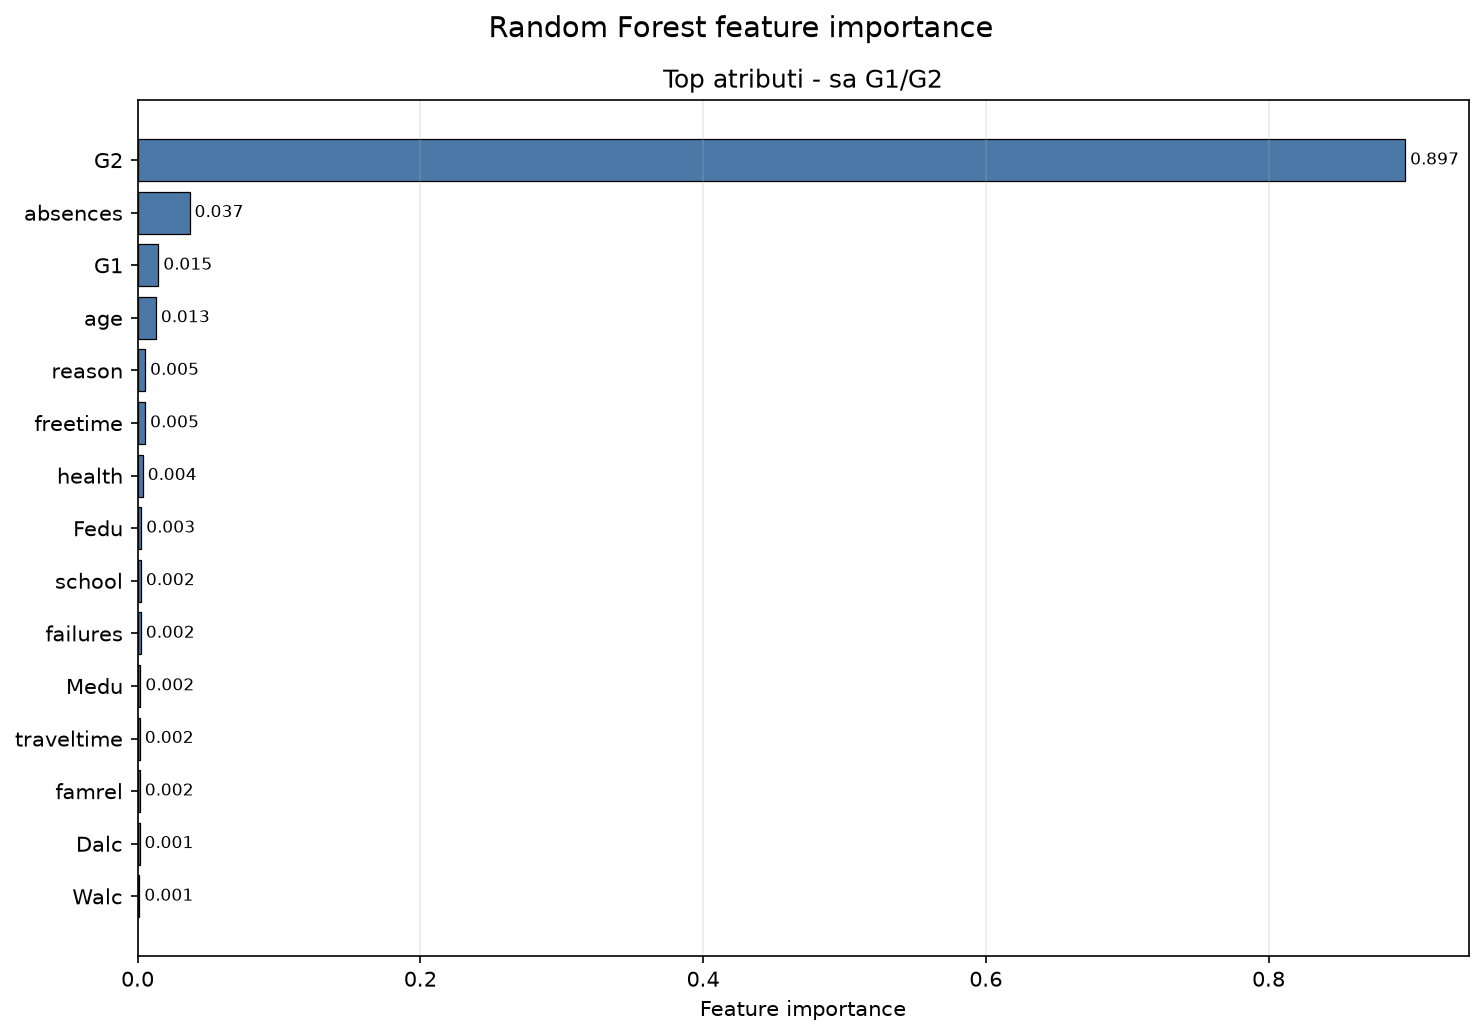

Feature importance bez G1/G2


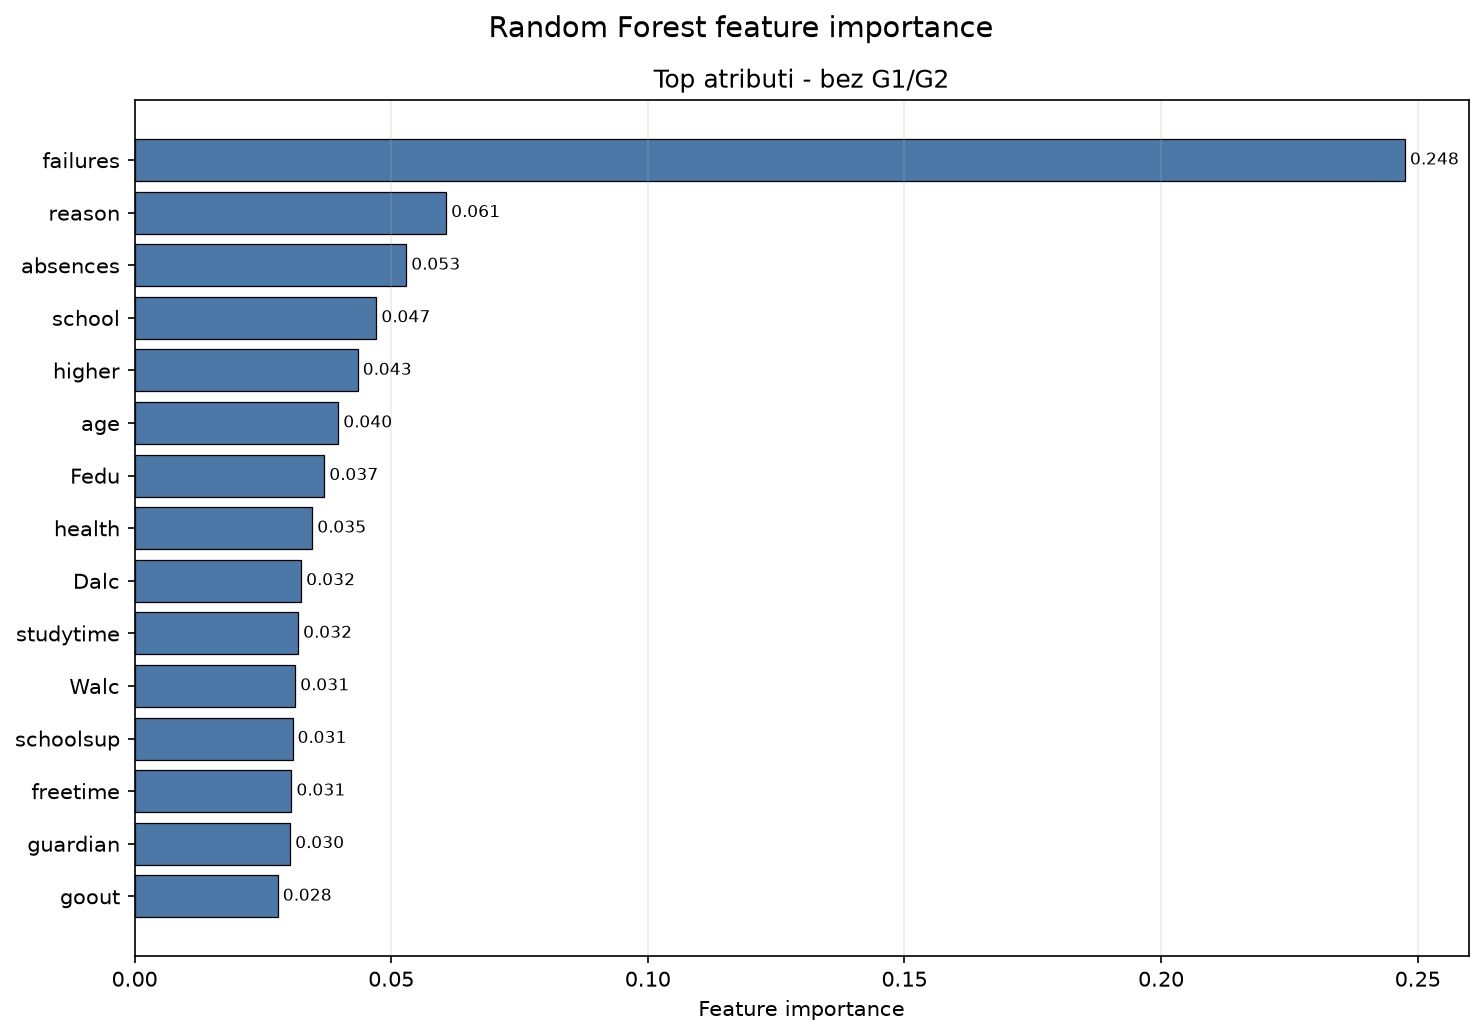

In [11]:
show_graphs(step08_graph_items)


U scenariju sa `G1/G2` očekivano dominiraju prethodne ocene, posebno `G2`, jer je vremenski najbliža završnoj oceni. Kada se `G1` i `G2` uklone, model se oslanja na druge dostupne signale, kao što su prethodni neuspesi, izostanci, razlog izbora škole i slični atributi.

Ovaj korak ne dokazuje uzročno-posledične veze. On pokazuje koje atribute je Random Forest najviše koristio za smanjenje greške predikcije i služi kao osnova za top features scenario.


## 10. Top features scenario

Top features scenario proverava da li manji broj najvažnijih atributa može dati sličan kvalitet kao puni skup atributa. Posebno su formirane dve liste najvažnijih atributa: jedna za scenario sa `G1/G2`, druga za scenario bez `G1/G2`.


In [12]:
top_features_best_rows = top_features_tuning_details[top_features_tuning_details["is_best"] == "Da"]

display(top_features_with_g1_g2)
display(top_features_without_g1_g2)
display(top_features_best_rows)
display(top_features_model_report)


,rank,feature,importance
0,1,G2,0.896595
1,2,absences,0.036763
2,3,G1,0.014654
3,4,age,0.012926
4,5,reason,0.005317
5,6,freetime,0.005300
6,7,health,0.003636
7,8,Fedu,0.002579
8,9,school,0.002357
9,10,failures,0.002284


,rank,feature,importance
0,1,failures,0.247520
1,2,reason,0.060714
2,3,absences,0.052936
3,4,school,0.047109
4,5,higher,0.043482
5,6,age,0.039692
6,7,Fedu,0.036970
7,8,health,0.034622
8,9,Dalc,0.032454
9,10,studytime,0.031868


,scenario,model,parameters,validation_MAE,validation_RMSE,validation_R2,is_best
0,top_features_with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=10; min_samples_leaf=5,0.6265,0.8656,0.9238,Da
1,top_features_with_G1_G2,Ridge Regression,alpha=0.01,0.6867,0.9735,0.9036,Da
2,top_features_without_G1_G2,RandomForestRegressor,n_estimators=200; max_depth=5; min_samples_leaf=1,2.0014,2.7076,0.2542,Da
3,top_features_without_G1_G2,Ridge Regression,alpha=10.0,1.9944,2.7461,0.2329,Da


,scenario,model,validation_MAE,validation_RMSE,validation_R2,test_MAE,test_RMSE,test_R2
0,with_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
1,with_G1_G2,Ridge Regression,0.7464,1.0457,0.8888,0.8256,1.3370,0.8518
2,with_G1_G2,RandomForestRegressor,0.6553,0.8831,0.9207,0.8287,1.4138,0.8343
3,top_features_with_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
4,top_features_with_G1_G2,Ridge Regression,0.6867,0.9735,0.9036,0.7671,1.2796,0.8642
5,top_features_with_G1_G2,RandomForestRegressor,0.6265,0.8656,0.9238,0.8437,1.4313,0.8301
6,without_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
7,without_G1_G2,Ridge Regression,2.0021,2.7782,0.2148,2.1474,2.9202,0.2929
8,without_G1_G2,RandomForestRegressor,2.0547,2.7633,0.2232,2.1991,2.9108,0.2974
9,top_features_without_G1_G2,DummyRegressor,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291


Top features comparison - validation


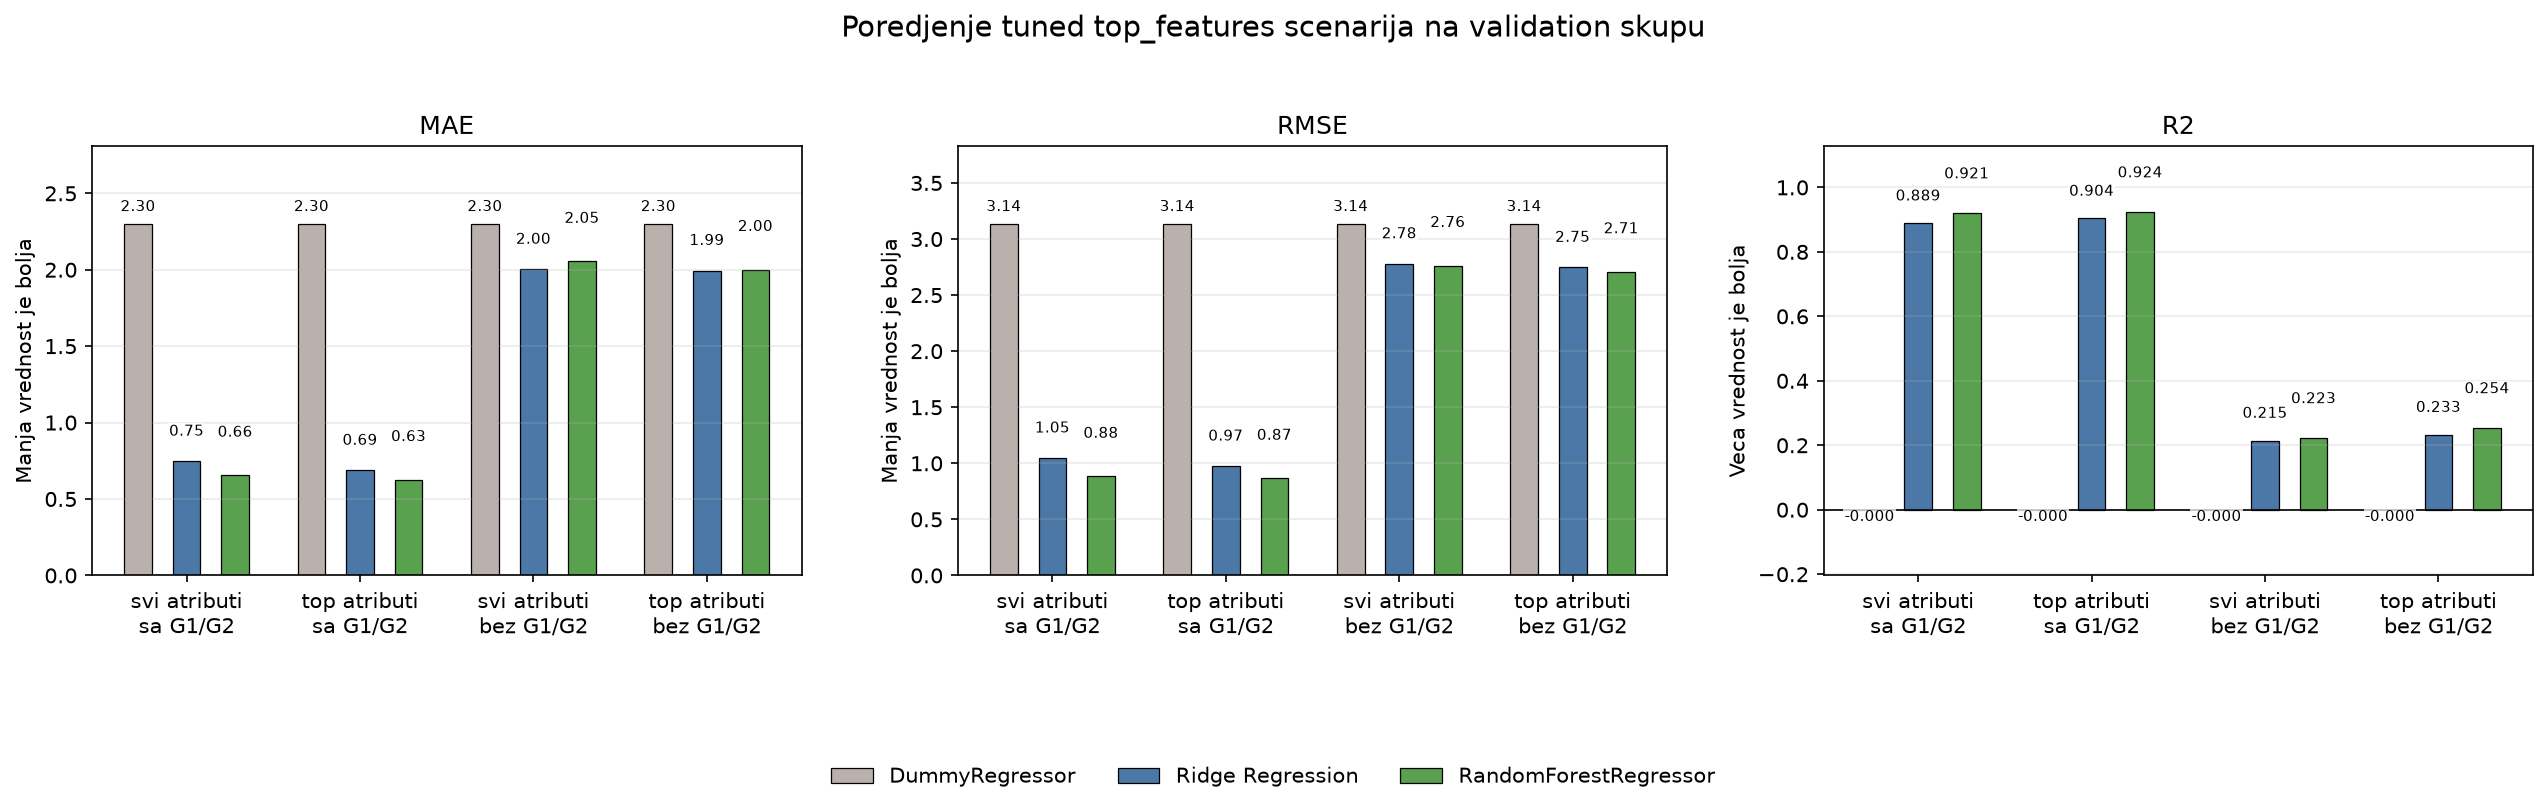

Top features comparison - test


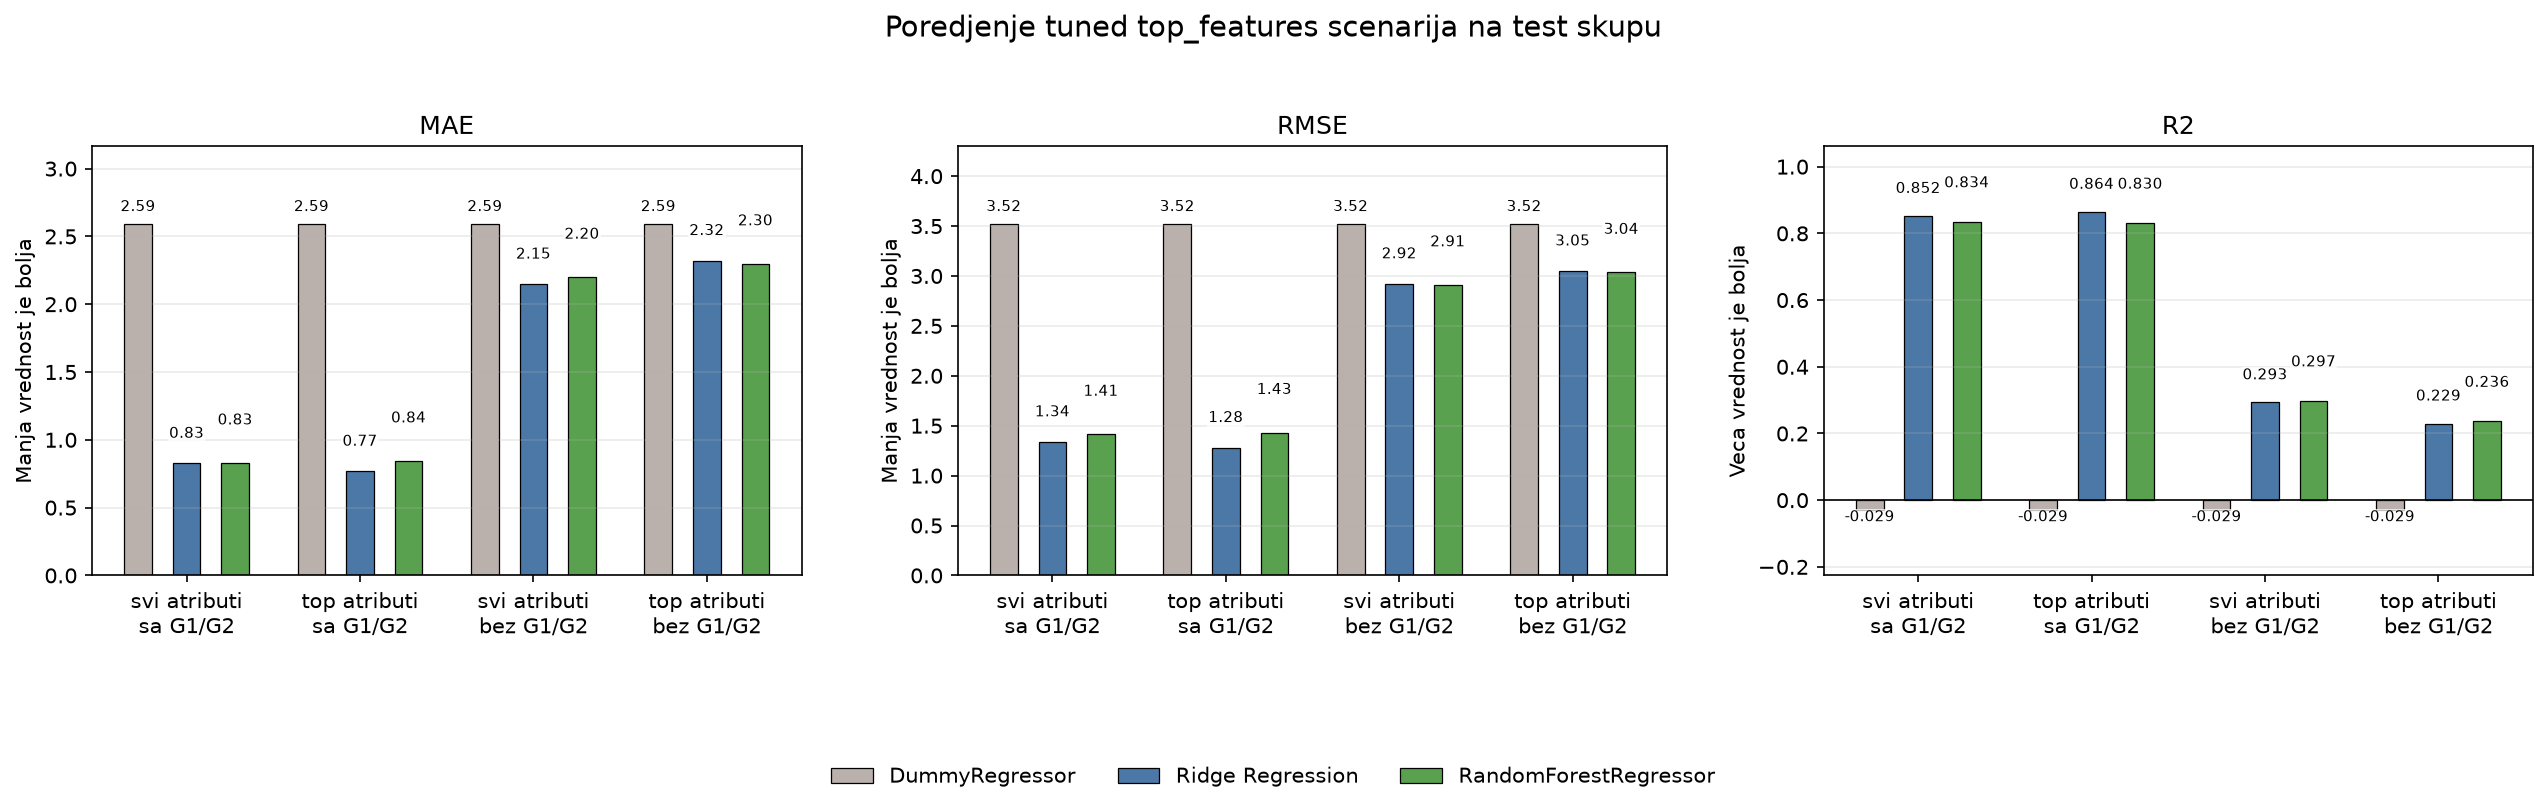

In [13]:
show_graphs(step09_graph_items)


Poređenje pokazuje kako se modeli ponašaju kada koriste sve atribute i kada koriste samo najbitnije atribute. Top features varijanta može pojednostaviti model i učiniti ga lakšim za tumačenje, ali ne garantuje automatski bolje metrike. Posebno u scenariju bez `G1/G2`, preostali atributi nose slabiji i indirektniji signal o završnoj oceni.


## 11. Izbor finalnog modela

Finalni model se bira na osnovu prethodnih poređenja, kvaliteta metrika, stabilnosti na test skupu i jednostavnosti upotrebe. Report prikazuje izabrani model, parametre i finalne test metrike.


In [14]:
display(final_model_report)
display(final_model_predictions.head(10))


,final_model_path,scenario,model,parameters,final_test_MAE,final_test_RMSE,final_test_R2,selection_reason
0,models/final/final_model.joblib,top_features_with_G1_G2,Ridge Regression,alpha=0.01,0.7655,1.2737,0.8655,"Izabran je Ridge Regression na top_features_with_G1_G2 scenariju jer daje jak validation rezultat, najbolji test RMSE medju poredjenim k..."


,actual_G3,predicted_G3,residual
0,12,13.0250,-1.0250
1,13,12.5856,0.4144
2,13,13.2759,-0.2759
3,14,14.5653,-0.5653
4,10,10.1942,-0.1942
5,15,15.3965,-0.3965
6,12,13.8418,-1.8418
7,15,15.3583,-0.3583
8,10,10.3940,-0.3940
9,12,13.0751,-1.0751


Final model metrics


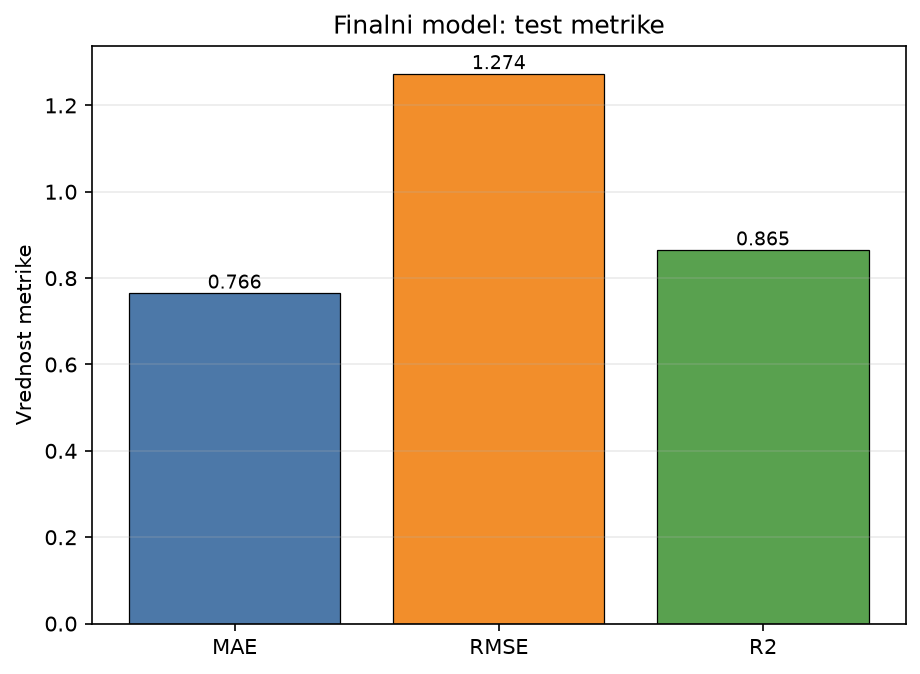

Actual vs predicted


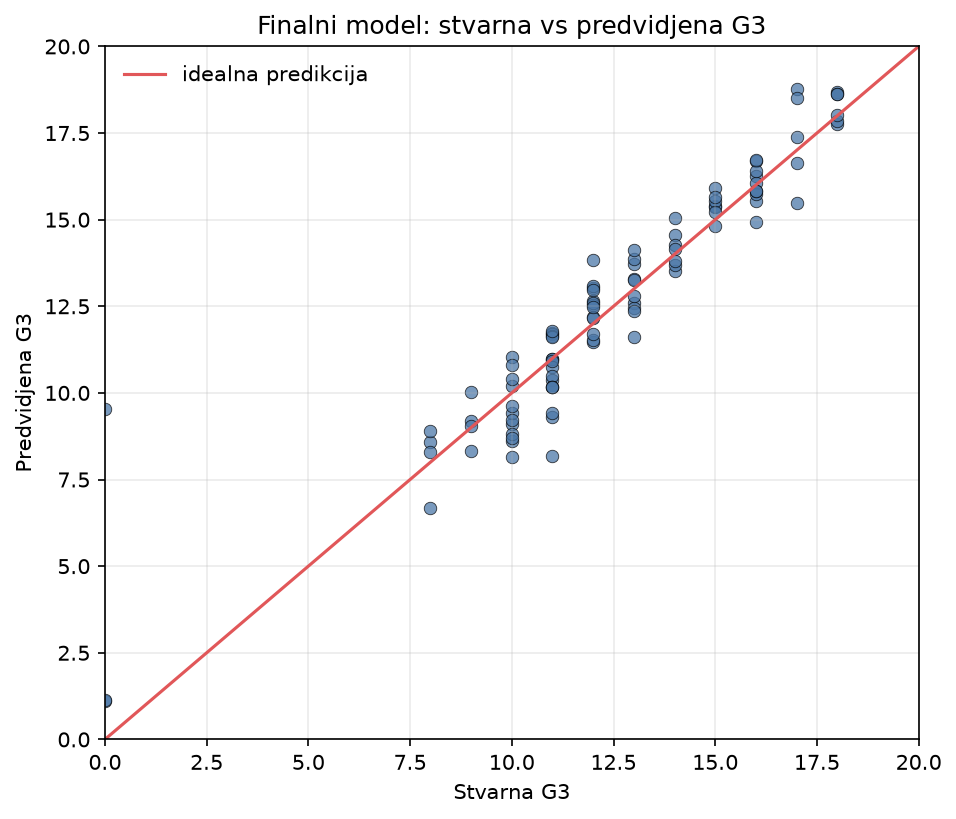

Residuals


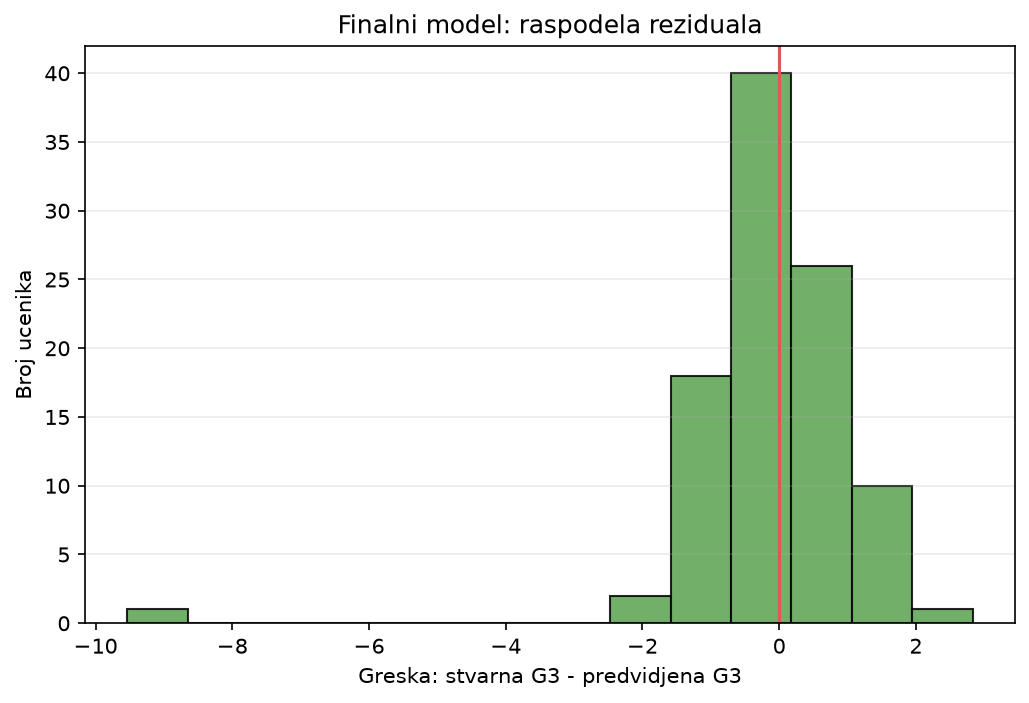

In [15]:
show_graphs(step10_graph_items)


Actual vs predicted graf poredi stvarne završne ocene sa predviđenim ocenama. Što su tačke bliže idealnoj dijagonali, to su predikcije preciznije.

Residuals graf prikazuje raspodelu grešaka, gde je **residual = stvarna G3 - predviđena G3**. Ako su reziduali uglavnom blizu nule, model nema velike sistematske greške na test skupu.

Finalni model ima dobar kvalitet za scenario u kojem su prethodne ocene dostupne. Njegovo glavno ograničenje je upravo to Što koristi `G1` i `G2`, pa nije najraniji mogući model za procenu uspeha učenika.


## 12. Korišćenje modela / deployment

Finalni model je eksportovan u folder `models/final/` kao `.joblib` fajl. Sačuvan je zajedno sa preprocessing pipeline-om i listom atributa koje očekuje, pa se za novu predikciju unose originalne vrednosti atributa, a pipeline interno radi skaliranje i enkodiranje.

U projektu postoje:

- `src/model_usage.py` - zajednička logika za učitavanje modela i predikciju;
- `src/predict.py` - CLI primer korišćenja modela;
- `src/streamlit_app.py` - jednostavan Streamlit UI za unos atributa i prikaz predikcije.


In [16]:
example_prediction = final_model_predictions.head(1).copy()
example_prediction.insert(0, "example", "Primer iz test skupa")

deployment_summary = pd.DataFrame([
    {
        "final_model_path": final_model_report.loc[0, "final_model_path"],
        "CLI primer": "python src/predict.py",
        "Streamlit UI": "streamlit run src/streamlit_app.py",
        "napomena": "Notebook ne učitava joblib model da bi radio i na kernelu bez joblib paketa.",
    }
])

display(example_prediction)
display(deployment_summary)


,example,actual_G3,predicted_G3,residual
0,Primer iz test skupa,12,13.025,-1.025


,final_model_path,CLI primer,Streamlit UI,napomena
0,models/final/final_model.joblib,python src/predict.py,streamlit run src/streamlit_app.py,Notebook ne učitava joblib model da bi radio i na kernelu bez joblib paketa.


Primer predikcije koristi podrazumevani ulaz iz `model_usage.py` i ne menja nijedan fajl. Isti mehanizam koriste CLI i Streamlit aplikacija.


## 13. Završni zaključak

Projekat pokriva ceo tok razvoja modela za predikciju završne ocene učenika: početnu proveru podataka, eksplorativnu analizu, podelu na train/validation/test skupove, treniranje više regresionih modela, podešavanje hiperparametara, feature importance analizu, top features scenarije i izbor finalnog modela.

Najvažniji nalaz je da `G1` i posebno `G2` imaju veoma jak uticaj na predikciju `G3`. Modeli koji koriste prethodne ocene daju znatno bolje rezultate, što je očekivano jer prethodni uspeh učenika nosi mnogo informacija o završnoj oceni. Sa druge strane, scenario bez `G1/G2` ima praktičnu vrednost jer omogućava raniju procenu uspeha kada prethodne ocene još nisu dostupne, iako su njegove metrike slabije.

Finalni model je sačuvan i može se koristiti za nove predikcije kroz CLI, pomoćne funkcije ili Streamlit aplikaciju. U praktičnoj upotrebi model može biti koristan kao pomoćni alat za procenu rizika i očekivanog uspeha, ali rezultate treba tumačiti uz ograničenja dataset-a i činjenicu da model sa `G1/G2` zavisi od već poznatih periodičnih ocena.
